# Transfer Learning

Este notebook explora o conceito de Transfer Learning (Aprendizagem por Transferência), uma técnica em deep learning que consiste em reutilizar um modelo pré-treinado em uma nova tarefa. Em vez de treinar uma rede neural do zero, o que exige grandes volumes de dados e poder computacional, podemos aproveitar o conhecimento encapsulado em modelos que foram treinados em datasets massivos, como o ImageNet.

In [1]:
import os
import time
import copy
import glob
import random
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, utils
import matplotlib.pyplot as plt

In [2]:
# Seleciona o dispositivo com prioridade: CUDA > MPS > CPU
_mps = getattr(torch.backends, "mps", None)
_mps_ok = _mps is not None and _mps.is_available()

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if _mps_ok
    else "cpu"
)

pin_memory = device.type == "cuda"
non_blocking = pin_memory

print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


## Dataset: Hymenoptera

Utilizaremos o dataset **Hymenoptera**, que é um pequeno subconjunto de imagens de formigas (*ants*) e abelhas (*bees*). Por ser um conjunto de dados bastante reduzido, treinar uma rede neural profunda do zero muito provavelmente levaria ao *overfitting*. É exatamente nesse cenário que o *Transfer Learning* brilha: vamos aproveitar o conhecimento de um modelo que já foi treinado em milhões de imagens para resolver o nosso problema de forma rápida e eficiente.

In [3]:
import requests
import zipfile
from io import BytesIO

if not os.path.exists('data/hymenoptera_data'):
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    response = requests.get(url)
    with zipfile.ZipFile(BytesIO(response.content)) as z:
        z.extractall("data/hymenoptera_data")
    print("Dataset 'hymenoptera_data' baixado e extraído.")
else:
    print("Dataset 'hymenoptera_data' já existe.")

Dataset 'hymenoptera_data' já existe.


In [4]:
from tl_hymenoptera_dataset import CustomImageDataset

In [5]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'data/hymenoptera_data'

# Criando instâncias de Dataset
train_dataset = CustomImageDataset(os.path.join(data_dir, 'train'), data_transforms['train'])
val_dataset = CustomImageDataset(os.path.join(data_dir, 'val'), data_transforms['val'])

# DataLoader: pin_memory só no CUDA; dataset em módulo importável permite num_workers > 0 no Jupyter
_num_workers = min(4, (os.cpu_count() or 1))
_dl_kwargs = dict(
    batch_size=4,
    num_workers=_num_workers,
    pin_memory=pin_memory,
    persistent_workers=_num_workers > 0,
)
train_dataloader = DataLoader(train_dataset, shuffle=True, **_dl_kwargs)
val_dataloader = DataLoader(val_dataset, shuffle=False, **_dl_kwargs)

# Obtendo informações
class_names = train_dataset.class_names
train_size = len(train_dataset)
val_size = len(val_dataset)

print(f"Classes: {class_names}")
print(f"Tamanho do dataset de treino: {train_size}")
print(f"Tamanho do dataset de validação: {val_size}")

Classes: ['bees', 'ants']
Tamanho do dataset de treino: 244
Tamanho do dataset de validação: 153


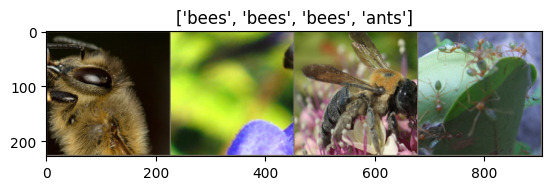

In [6]:
def imshow(inp, title=None):
    """Função para exibir um tensor de imagem."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Obtém um batch de dados de treino
inputs, classes = next(iter(train_dataloader))

# Cria uma grade a partir do batch
out = utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Treinamento de um Modelo Baseline

Para entender o efeito do transfer learning, primeiro treinaremos uma rede convolucional (CNN) simples a partir do zero. Dado o tamanho reduzido do nosso dataset, é altamente provável que este modelo sofra de overfitting, o que servirá como um ponto de referência.

In [7]:
from tqdm.notebook import tqdm

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=25):
    history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc']}

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')

        for phase, loader in {'train': train_loader, 'val': val_loader}.items():
            model.train(phase == 'train')
            loss_sum, correct = 0.0, 0

            for x, y in tqdm(loader, desc=phase.capitalize()):
                x = x.to(device, non_blocking=non_blocking)
                y = y.to(device, non_blocking=non_blocking)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    out = model(x)
                    loss = criterion(out, y)
                    pred = out.argmax(1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                loss_sum += loss.item() * x.size(0)
                correct += (pred == y).sum().item()

            n = len(loader.dataset)
            epoch_loss, epoch_acc = loss_sum / n, correct / n

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return history


def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Validation Loss')
    ax1.set_title('Model Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history['train_acc'], label='Train Accuracy')
    ax2.plot(history['val_acc'], label='Validation Accuracy')
    ax2.set_title('Model Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    plt.show()

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=len(class_names)):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Flatten(),
            nn.Linear(32 * 56 * 56, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.model(x)

baseline_model = SimpleCNN().to(device)

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer_baseline = optim.Adam(baseline_model.parameters(), lr=0.001)

history_baseline = train_model(
    baseline_model, criterion, optimizer_baseline, train_dataloader, val_dataloader, num_epochs=25
)


Epoch 1/25


Train:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss: 1.2983 Acc: 0.5697


Val:   0%|          | 0/39 [00:00<?, ?it/s]

Val Loss: 0.7328 Acc: 0.5163

Epoch 2/25


...

Val Loss: 0.8120 Acc: 0.7059

Epoch 25/25


Train:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss: 0.5421 Acc: 0.7377


Val:   0%|          | 0/39 [00:00<?, ?it/s]

Val Loss: 0.5929 Acc: 0.7712


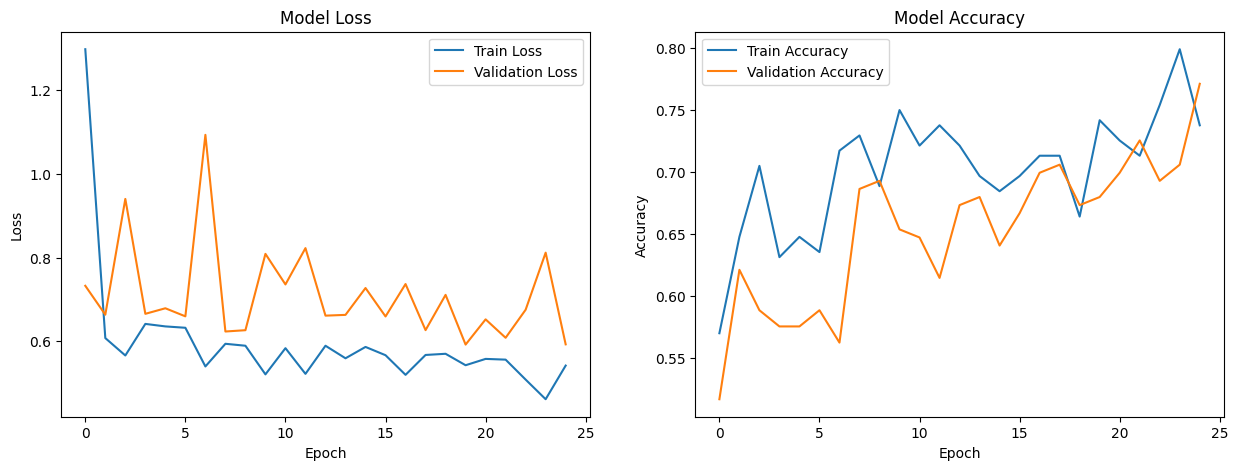

In [10]:
plot_history(history_baseline)

## Modelos Pré-treinados

O módulo `torchvision.models` fornece acesso a diversas arquiteturas de redes neurais conhecidas, como VGG, ResNet e EfficientNet, que já foram previamente treinadas no gigantesco dataset ImageNet, que contém 1000 categorias diferentes. Esses modelos já aprenderam a identificar uma hierarquia rica de características visuais, indo de formas e texturas básicas até partes complexas de objetos. O objetivo é importar um desses modelos e utilizar seus pesos já ajustados como ponto de partida.

In [11]:
from torchvision import models

# Carregando um modelo ResNet-50 pré-treinado
weights = models.ResNet50_Weights.DEFAULT
resnet50_pretrained = models.resnet50(weights=weights)
resnet50_pretrained = resnet50_pretrained.to(device)

# A última camada 'fc' (fully connected) tem 1000 saídas,
# correspondentes às 1000 classes do ImageNet.
print(resnet50_pretrained)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/gilcesarf/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [01:56<00:00, 883kB/s]  


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Usando um Modelo Pré-treinado para Inferência

Um modelo pré-treinado pode ser usado diretamente para inferência. Basta carregá-lo, colocá-lo em modo de avaliação com `.eval()` e passar uma imagem pré-processada. A saída será um vetor de scores para as 1000 classes do ImageNet.

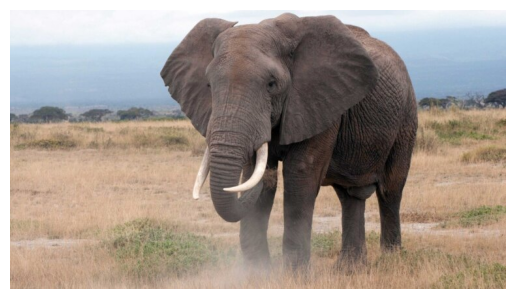

In [12]:
url = "https://www.uni-jena.de/unijenamedia/387585/elefant.jpg?height=428&width=760"
response = requests.get(url, stream=True)
img = Image.open(response.raw)

plt.imshow(img)
plt.axis('off')
plt.show()

In [13]:
preprocess = data_transforms['val']
img_tensor = preprocess(img).unsqueeze(0)

print(preprocess)
print(img_tensor.shape)

Compose(
    Resize(size=256, interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
torch.Size([1, 3, 224, 224])


In [14]:
resnet50_pretrained.eval()
with torch.no_grad():
    output = resnet50_pretrained(img_tensor.to(device, non_blocking=non_blocking))

print(output.shape)

torch.Size([1, 1000])


In [15]:
probabilities = torch.nn.functional.softmax(output[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)

for i in range(top5_prob.size(0)):
    print(f"Classe: {weights.meta['categories'][top5_catid[i]]}, Probabilidade: {top5_prob[i].item():.4f}")

Classe: African elephant, Probabilidade: 0.3498
Classe: tusker, Probabilidade: 0.2966
Classe: Indian elephant, Probabilidade: 0.0079
Classe: Great Dane, Probabilidade: 0.0009
Classe: promontory, Probabilidade: 0.0007


### Transfer Learning: Congelando Camadas (Freezing)

Na abordagem de Extração de Características, nós congelamos os parâmetros de toda a rede pré-treinada, ou seja, impedimos que eles sejam atualizados durante o nosso treinamento. Fazemos isso definindo `requires_grad = False` para esses pesos. Em seguida, descartamos a camada final original, que classificava 1000 categorias, e adicionamos uma nova camada linear ajustada para o nosso problema, que possui apenas 2 categorias. Dessa forma, durante o backpropagation, apenas os pesos dessa última camada recém-adicionada serão otimizados, poupando poder computacional e evitando que os pesos bons da rede original sejam corrompidos.

In [16]:
model_conv = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Congelar todos os parâmetros da rede
for param in model_conv.parameters():
    param.requires_grad = False

print(model_conv)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [17]:
num_ftrs = model_conv.fc.in_features

# Substituir a camada 'fc' por uma nova camada Linear
# Os parâmetros desta nova camada terão `requires_grad=True` por padrão
model_conv.fc = nn.Linear(num_ftrs, len(class_names))

model_conv = model_conv.to(device)

print("Estrutura da última camada modificada:")
print(model_conv.fc)

Estrutura da última camada modificada:
Linear(in_features=2048, out_features=2, bias=True)


### Treinando o Modelo com Transfer Learning

Agora, vamos treinar o modelo modificado. O otimizador Adam será configurado para atualizar apenas os parâmetros da nova camada de classificação. Esperamos ver uma convergência muito mais rápida e uma acurácia de validação significativamente maior em comparação com o modelo baseline.

In [18]:
criterion = nn.CrossEntropyLoss()
optimizer_conv = optim.Adam(model_conv.fc.parameters(), lr=0.001)

# Treinar o modelo
history_conv = train_model(
    model_conv, criterion, optimizer_conv, train_dataloader, val_dataloader, num_epochs=5
)


Epoch 1/5


Train:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss: 0.5375 Acc: 0.7951


Val:   0%|          | 0/39 [00:00<?, ?it/s]

Val Loss: 0.3337 Acc: 0.9346

Epoch 2/5


...

Val Loss: 0.1925 Acc: 0.9739

Epoch 5/5


Train:   0%|          | 0/61 [00:00<?, ?it/s]

Train Loss: 0.3399 Acc: 0.8648


Val:   0%|          | 0/39 [00:00<?, ?it/s]

Val Loss: 0.1585 Acc: 0.9608


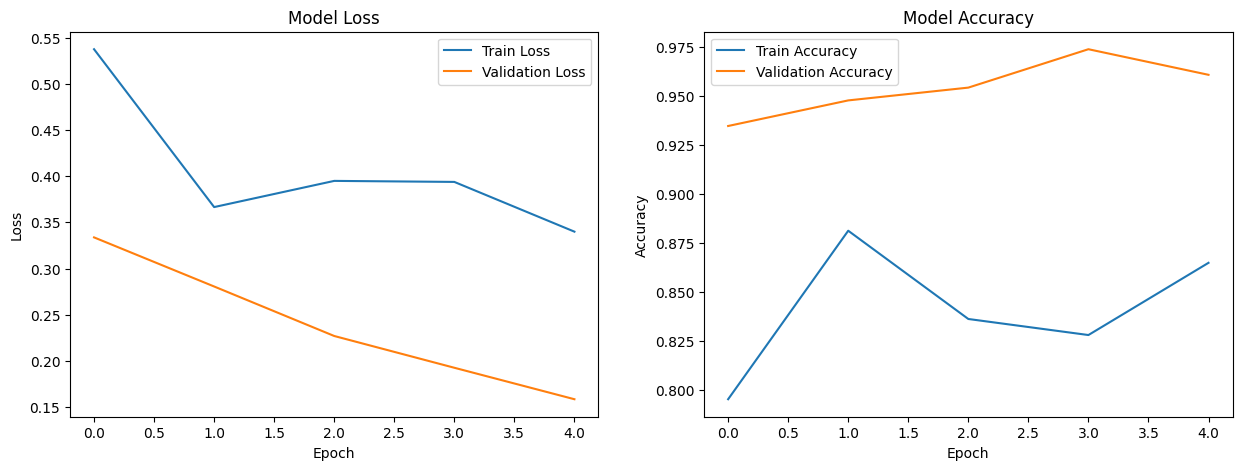

In [19]:
plot_history(history_conv)

### Inferência

Com o modelo treinado, podemos agora usá-lo para realizar previsões (inferência) em imagens do conjunto de validação para observar visualmente o seu desempenho.

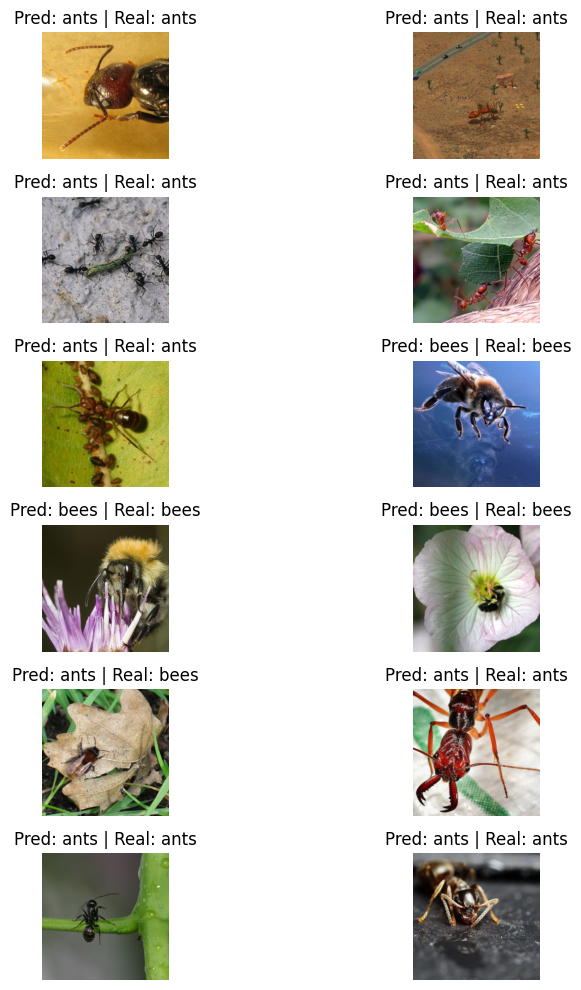

In [20]:
model_conv.eval()

num_images = 12
plt.figure(figsize=(10, 10))

indices = random.sample(range(len(val_dataloader.dataset)), num_images)

with torch.no_grad():
    for i, idx in enumerate(indices):
        img, label = val_dataloader.dataset[idx]

        input_tensor = img.unsqueeze(0).to(device)
        label = torch.tensor([label]).to(device)

        pred = model_conv(input_tensor).argmax(1)

        plt.subplot(num_images // 2, 2, i + 1)
        plt.axis('off')
        plt.title(f'Pred: {class_names[pred.item()]} | Real: {class_names[label.item()]}')

        img_np = img.cpu().numpy().transpose(1, 2, 0)
        img_np = np.clip(
            img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406],
            0, 1
        )
        plt.imshow(img_np)

plt.tight_layout()
plt.show()

## Salvando e Carregando Modelos

Após investir tempo treinando (ou aplicando *fine-tuning* a) um modelo, é importante salvar os pesos aprendidos para usá-los posteriormente sem precisar treinar tudo novamente. A abordagem recomendada pelo PyTorch é salvar o `state_dict`, que é um dicionário contendo todos os pesos e *bias* (vieses) da rede.

In [21]:
# Caminho para salvar o modelo
model_path = 'bees_ants_model.pth'

# Salvando o state_dict
torch.save(model_conv.state_dict(), model_path)
print(f"Modelo salvo em {model_path}")

Modelo salvo em bees_ants_model.pth


Para carregar, precisamos primeiro instanciar a mesma arquitetura do modelo original e, em seguida, carregar os pesos no modelo.

In [22]:
# Instanciando o modelo novamente (mesma arquitetura)
model_loaded = models.resnet50()
num_ftrs = model_loaded.fc.in_features
model_loaded.fc = nn.Linear(num_ftrs, len(class_names))

# Carregando os pesos guardados
model_loaded.load_state_dict(torch.load(model_path, map_location=device))
model_loaded = model_loaded.to(device)
model_loaded.eval() # Colocando em modo de inferência para evitar treinamento acidental
print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


## Exercícios

### Exercício 1

Descongele mais das últimas camadas (à sua escolha), por exemplo `model.layer4[1]`, e treine novamente o modelo.

### Exercício 2

Escolha outro modelo pré-treinado em [Torchvision Models](https://docs.pytorch.org/vision/main/models.html) e substitua no modelo. Lembre-se de alterar a última camada de classificação.